# Experimento 1: Sensibilidad al Tamaño de la Ventana y Stride

El objetivo de este cuadernillo es evaluar el efecto de variar el tamaño de la ventana (W) y el solapamiento o stride (S) en la exactitud del sistema.
Realizaremos una búsqueda 2D entrenando los 4 modelos (SVM, Random Forest, CNN-LSTM y CNN-TCN) para encontrar el "sweet spot" de resolución vs retardo, de forma independiente para el músculo Flexor (FDS) y Extensor (ED).


In [2]:
import sys
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import numpy as np
# Añadir el directorio padre al path para importar 'src'
sys.path.append(os.path.abspath('../..'))

import tensorflow as tf

# 🚀 Detección y Configuración de GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"🚀 GPU detectada y activada para Deep Learning: {gpus[0].name}")
    except RuntimeError as e:
        print(e)
else:
    print("ℹ️ No se detectó GPU, ejecutando en CPU.")

import matplotlib.pyplot as plt
import seaborn as sns
from src import dataset, features
from src.models import rf, svm, cnn_lstm, cnn_tcn


🚀 GPU detectada y activada para Deep Learning: /physical_device:GPU:0


In [3]:
window_sizes = [100, 150, 200, 250, 300]
strides = [25, 50, 100]
muscles = ['FDS', 'ED']
subject = 'S01'

# Guardaremos diccionarios anidados: results_model[muscle][window][stride] = accuracy
results_svm  = {m: {w: {} for w in window_sizes} for m in muscles}
results_rf   = {m: {w: {} for w in window_sizes} for m in muscles}
results_lstm = {m: {w: {} for w in window_sizes} for m in muscles}
results_tcn  = {m: {w: {} for w in window_sizes} for m in muscles}

for muscle in muscles:
    print(f"\n{'='*50}")
    print(f"=== EVALUANDO MÚSCULO: {muscle} ===")
    print(f"{'='*50}")
    for w in window_sizes:
        for s in strides:
            print(f"\n[*] Procesando Ventana = {w} ms | Stride = {s} ms ...")
            
            # 1. Cargar tensores crudos
            try:
                X_train_raw, y_train, X_test_raw, y_test = dataset.load_and_segment_dataset(
                    subject=subject,
                    muscle=muscle,
                    window_size=w,
                    overlap=s
                )
            except Exception as e:
                print(f"  [!] Error al cargar dataset: {e}. Saltando...")
                continue
                
            # 2. Extraer características para ML Clásico
            X_train_feat = features.extract_features(X_train_raw, subject=subject, muscle=muscle)
            X_test_feat = features.extract_features(X_test_raw, subject=subject, muscle=muscle)
            
            # 3. Escalar características (solo necesario para SVM y Redes)
            X_train_scaled, X_test_scaled, scaler = features.scale_features(X_train_feat, X_test_feat)
            
            # ---------------------------------------------------------
            # ENTRENAMIENTO SVM (GridSearch CPU - Con Escalamiento)
            # ---------------------------------------------------------
            print("  -> Entrenando SVM (GridSearch)...")
            model_svm = svm.train_with_gridsearch(X_train_scaled, y_train)
            acc_svm, _ = svm.evaluate(model_svm, X_test_scaled, y_test)
            results_svm[muscle][w][s] = acc_svm
            print(f"     [SVM] Exactitud: {acc_svm * 100:.2f}%")
            
            # ---------------------------------------------------------
            # ENTRENAMIENTO RF (GridSearch CPU - SIN Escalar)
            # ---------------------------------------------------------
            print("  -> Entrenando RF (GridSearch)...")
            model_rf = rf.train_with_gridsearch(X_train_feat, y_train)
            acc_rf, _ = rf.evaluate(model_rf, X_test_feat, y_test)
            results_rf[muscle][w][s] = acc_rf
            print(f"     [RF]  Exactitud: {acc_rf * 100:.2f}%")
            
            # ---------------------------------------------------------
            # ENTRENAMIENTO CNN-LSTM (Deep Learning - Crudos)
            # ---------------------------------------------------------
            print("  -> Entrenando CNN-LSTM (Deep Learning)...")
            model_lstm_base = cnn_lstm.build_model(window_size=w)
            # Usamos 10 epochs para la búsqueda para no demorar días
            model_lstm = cnn_lstm.train_with_pruning(model_lstm_base, X_train_raw, y_train, epochs=10, batch_size=32)
            
            X_test_dl = np.expand_dims(X_test_raw, axis=-1) if X_test_raw.ndim == 2 else X_test_raw
            _, acc_lstm = model_lstm.evaluate(X_test_dl, y_test, verbose=0)
            results_lstm[muscle][w][s] = acc_lstm
            print(f"     [CNN-LSTM] Exactitud: {acc_lstm * 100:.2f}%")
            
            # ---------------------------------------------------------
            # ENTRENAMIENTO CNN-TCN (Deep Learning - Crudos)
            # ---------------------------------------------------------
            print("  -> Entrenando CNN-TCN (Deep Learning)...")
            model_tcn_base = cnn_tcn.build_model(window_size=w)
            # Usamos 10 epochs para la búsqueda para no demorar días
            model_tcn = cnn_tcn.train_with_pruning(model_tcn_base, X_train_raw, y_train, epochs=10, batch_size=32)
            
            _, acc_tcn = model_tcn.evaluate(X_test_dl, y_test, verbose=0)
            results_tcn[muscle][w][s] = acc_tcn
            print(f"     [CNN-TCN]  Exactitud: {acc_tcn * 100:.2f}%")



=== EVALUANDO MÚSCULO: FDS ===

[*] Procesando Ventana = 100 ms | Stride = 25 ms ...
  -> Entrenando SVM (GridSearch)...
Fitting 5 folds for each of 90 candidates, totalling 450 fits
     [SVM] Exactitud: 76.61%
  -> Entrenando RF (GridSearch)...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
     [RF]  Exactitud: 77.50%
  -> Entrenando CNN-LSTM (Deep Learning)...


I0000 00:00:1787694244.948275   88359 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2254 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2050, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/10


I0000 00:00:1787694250.113833   93332 cuda_dnn.cc:461] Loaded cuDNN version 91801
I0000 00:00:1787694251.368692   93332 service.cc:153] XLA service 0x7f749ab492b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787694251.368715   93332 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 2050, Compute Capability 8.6 (Driver: 12.4.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.18.1)
I0000 00:00:1787694251.381063   93332 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787694251.445971   93332 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


230/230 [==============================] - 10s 17ms/step - loss: 0.7918 - accuracy: 0.6298
Epoch 2/10
230/230 [==============================] - 2s 8ms/step - loss: 0.6640 - accuracy: 0.6926
Epoch 3/10
230/230 [==============================] - 2s 9ms/step - loss: 0.6357 - accuracy: 0.7045
Epoch 4/10
230/230 [==============================] - 2s 9ms/step - loss: 0.6253 - accuracy: 0.7152
Epoch 5/10
230/230 [==============================] - 2s 8ms/step - loss: 0.6148 - accuracy: 0.7225
Epoch 6/10
230/230 [==============================] - 2s 8ms/step - loss: 0.6110 - accuracy: 0.7236
Epoch 7/10
230/230 [==============================] - 2s 8ms/step - loss: 0.6043 - accuracy: 0.7291
Epoch 8/10
230/230 [==============================] - 2s 9ms/step - loss: 0.6077 - accuracy: 0.7212
Epoch 9/10
230/230 [==============================] - 2s 9ms/step - loss: 0.5976 - accuracy: 0.7406
Epoch 10/10
230/230 [==============================] - 2s 8ms/step - loss: 0.5929 - accuracy: 0.7332
     [CN

W0000 00:00:1787695252.676251   93326 bfc_allocator.cc:383] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may try smaller batch sizes to observe the performance impact. Set TF_ENABLE_GPU_GARBAGE_COLLECTION=false if you'd like to disable this feature.
W0000 00:00:1787695254.208740   93326 bfc_allocator.cc:311] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.03GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


218/218 [==============================] - 10s 14ms/step - loss: 0.6895 - accuracy: 0.6839
Epoch 2/10
218/218 [==============================] - 3s 14ms/step - loss: 0.5594 - accuracy: 0.7377
Epoch 3/10
218/218 [==============================] - 3s 14ms/step - loss: 0.5423 - accuracy: 0.7392
Epoch 4/10
218/218 [==============================] - 3s 14ms/step - loss: 0.5240 - accuracy: 0.7557
Epoch 5/10
218/218 [==============================] - 3s 14ms/step - loss: 0.5053 - accuracy: 0.7665
Epoch 6/10
218/218 [==============================] - 3s 14ms/step - loss: 0.5194 - accuracy: 0.7616
Epoch 7/10
218/218 [==============================] - 3s 14ms/step - loss: 0.4972 - accuracy: 0.7662
Epoch 8/10
218/218 [==============================] - 3s 14ms/step - loss: 0.4862 - accuracy: 0.7704
Epoch 9/10
218/218 [==============================] - 3s 14ms/step - loss: 0.4820 - accuracy: 0.7731
Epoch 10/10
218/218 [==============================] - 3s 14ms/step - loss: 0.4749 - accuracy: 0.7758

## Visualización de los Mapas Térmicos (Heatmaps)
Graficaremos el espacio de búsqueda 2D para cada modelo y músculo.


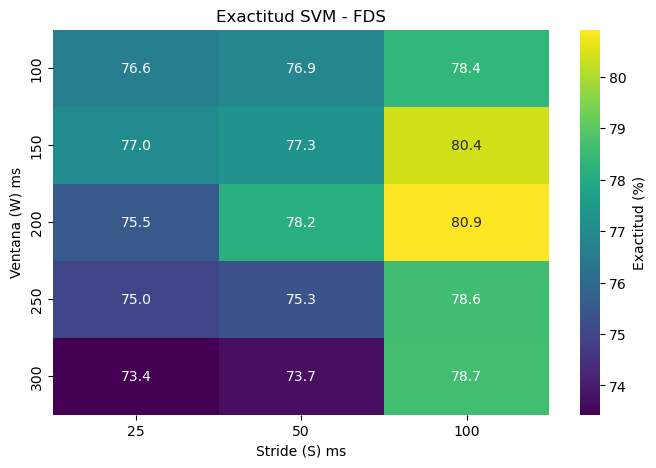

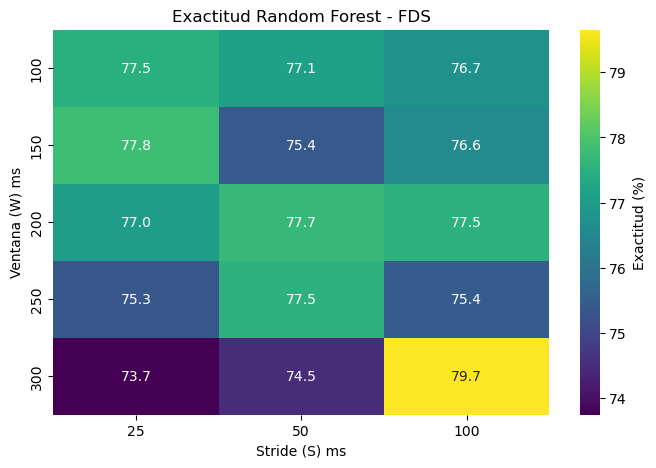

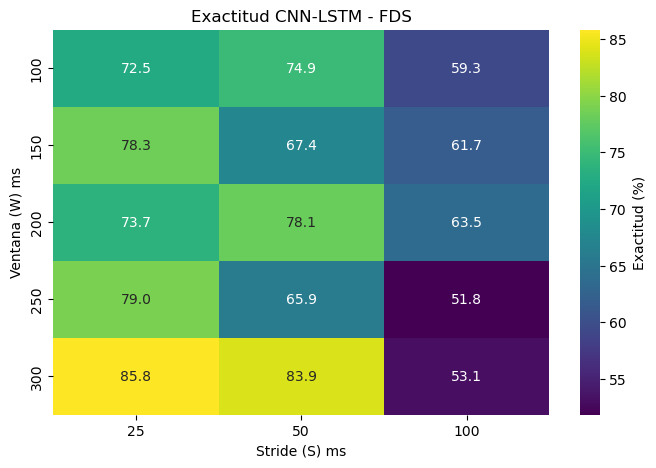

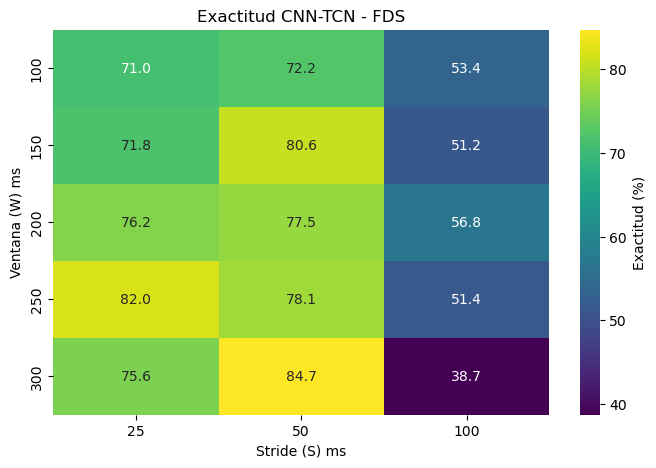

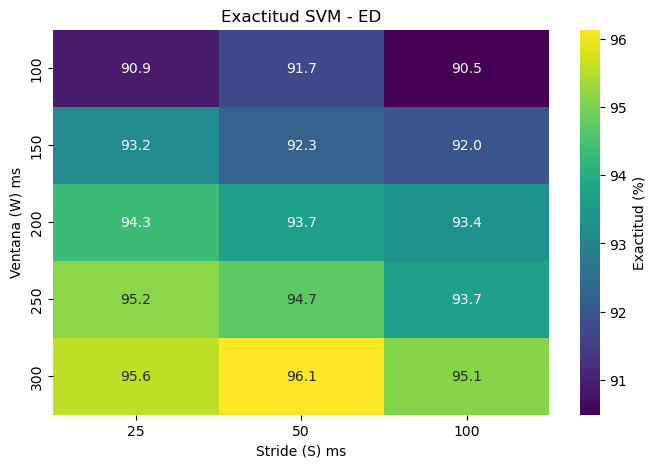

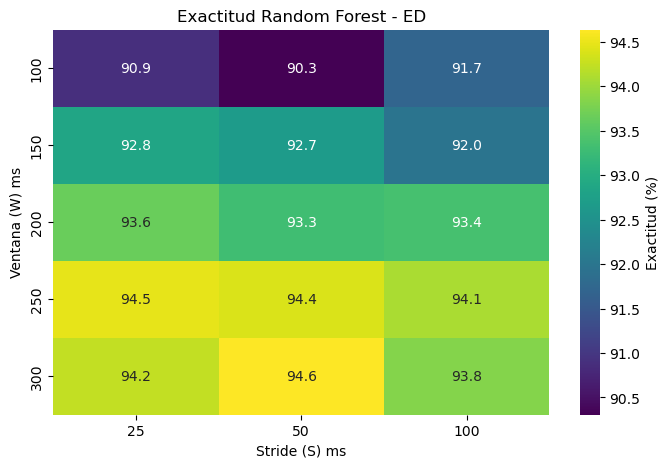

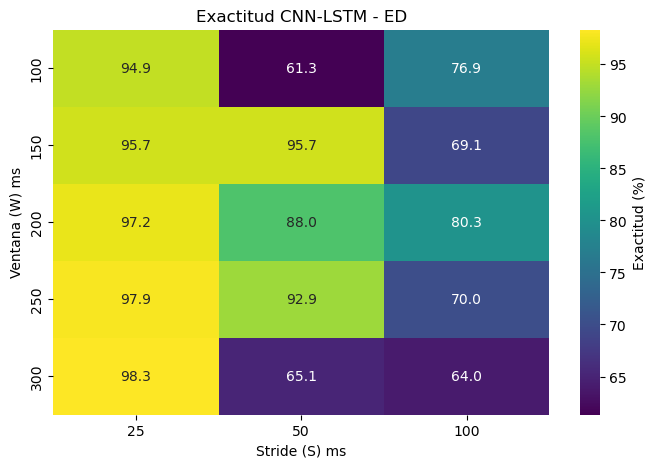

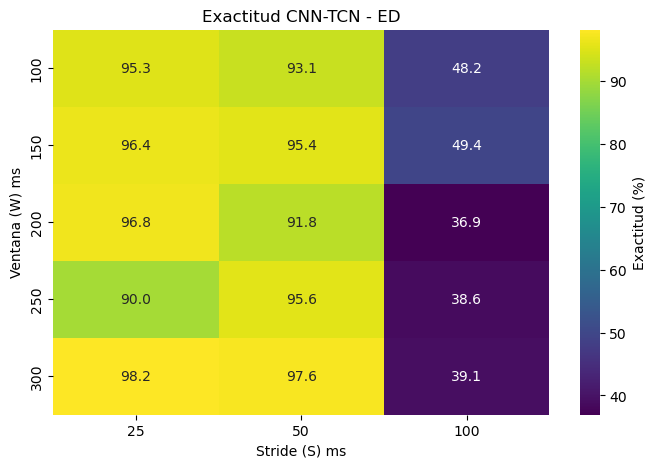

In [4]:
import pandas as pd

def plot_heatmap(results_dict, muscle_name, model_name):
    df = pd.DataFrame(results_dict[muscle_name]).T
    df.columns.name = 'Stride (S) ms'
    df.index.name = 'Ventana (W) ms'
    
    plt.figure(figsize=(8, 5))
    sns.heatmap(df * 100, annot=True, fmt=".1f", cmap='viridis', cbar_kws={'label': 'Exactitud (%)'})
    plt.title(f'Exactitud {model_name} - {muscle_name}')
    plt.show()

for m in muscles:
    plot_heatmap(results_svm, m, 'SVM')
    plot_heatmap(results_rf, m, 'Random Forest')
    plot_heatmap(results_lstm, m, 'CNN-LSTM')
    plot_heatmap(results_tcn, m, 'CNN-TCN')


## Generación Automática de Configuración (`config.py`)
Exportaremos los mejores parámetros encontrados para que los siguientes experimentos los consuman automáticamente.


In [5]:
import os
import json
from pathlib import Path

# Buscamos la combinación que maximiza la exactitud
def get_best(results_dict, muscle):
    best_w, best_s, best_acc = None, None, -1
    for w in results_dict[muscle]:
        for s in results_dict[muscle][w]:
            acc = results_dict[muscle][w][s]
            if acc > best_acc:
                best_acc = acc
                best_w = w
                best_s = s
    return {"WINDOW": best_w, "STRIDE": best_s, "ACCURACY": round(best_acc * 100, 2) if best_acc is not None else 0.0}

best_params = {
    "FDS": {
        "SVM": get_best(results_svm, "FDS"),
        "RF": get_best(results_rf, "FDS"),
        "CNN-LSTM": get_best(results_lstm, "FDS"),
        "CNN-TCN": get_best(results_tcn, "FDS")
    },
    "ED": {
        "SVM": get_best(results_svm, "ED"),
        "RF": get_best(results_rf, "ED"),
        "CNN-LSTM": get_best(results_lstm, "ED"),
        "CNN-TCN": get_best(results_tcn, "ED")
    }
}

print("Los mejores hiperparámetros encontrados son:")
print(best_params)

# Exportación a la carpeta src/ (un nivel arriba)
ruta_config = "../config.py"

with open(ruta_config, "w", encoding="utf-8") as f:
    f.write("BEST_PARAMS = ")
    
    # Escribimos el diccionario
    f.write(json.dumps(best_params, indent=4))
    f.write("\n\n")
    
    # Inyectamos la función ayudante al final del archivo
    f.write("def get_best_window_stride(muscle, model_name):\n")
    f.write("    \"\"\"Retorna la tupla (window_size, stride) óptima.\"\"\"\n")
    f.write("    params = BEST_PARAMS.get(muscle, {}).get(model_name)\n")
    f.write("    if params is None and model_name == 'CNN':\n")
    f.write("        params = BEST_PARAMS.get(muscle, {}).get('CNN-LSTM', {})\n")
    f.write("    elif params is None:\n")
    f.write("        params = {}\n")
    f.write("    return params.get('WINDOW', 300), params.get('STRIDE', 50)\n")

print(f"\n✅ Archivo exportado exitosamente en: {Path(ruta_config).resolve()}")


Los mejores hiperparámetros encontrados son:
{'FDS': {'SVM': {'WINDOW': 200, 'STRIDE': 100, 'ACCURACY': 80.92}, 'RF': {'WINDOW': 300, 'STRIDE': 100, 'ACCURACY': 79.65}, 'CNN-LSTM': {'WINDOW': 300, 'STRIDE': 25, 'ACCURACY': 85.8}, 'CNN-TCN': {'WINDOW': 300, 'STRIDE': 50, 'ACCURACY': 84.73}}, 'ED': {'SVM': {'WINDOW': 300, 'STRIDE': 50, 'ACCURACY': 96.14}, 'RF': {'WINDOW': 300, 'STRIDE': 50, 'ACCURACY': 94.64}, 'CNN-LSTM': {'WINDOW': 300, 'STRIDE': 25, 'ACCURACY': 98.33}, 'CNN-TCN': {'WINDOW': 300, 'STRIDE': 25, 'ACCURACY': 98.22}}}

✅ Archivo exportado exitosamente en: /home/cbe/Proyectos/MyoTensor_Tesis/intelligence/src/config.py
